In [1]:
import os
import sys

# 현재 작업 디렉토리 확인해보고
print("CWD:", os.getcwd())

# notebooks/ 에서 한 단계 위(프로젝트 루트)로 올라가기
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT:", PROJECT_ROOT)

# sys.path 에 프로젝트 루트가 없으면 추가
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path")


CWD: c:\Users\user\Desktop\project\scalp-vision-agent\notebooks
PROJECT_ROOT: c:\Users\user\Desktop\project\scalp-vision-agent
Added to sys.path


In [2]:
import torch
from torch.utils.data import DataLoader
from torch import optim

from src.config import MASTER_INDEX_CSV
from src.cnn.dataset import ScalpDataset
from src.cnn.models import MultiHeadResNet18
from src.cnn.utils import labels_dict_to_tensor
from src.cnn.losses import multihead_ce_loss
from src.cnn.train import get_device, train_one_epoch, evaluate_one_epoch, train_model


In [3]:
device = get_device()
device


device(type='cuda')

In [4]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4


In [5]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])


In [6]:
from torch.utils.data import Subset

train_dataset = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="train", transforms=train_transform)
val_dataset   = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="val",   transforms=val_transform)

print(len(train_dataset), len(val_dataset))


67588 23568


In [7]:
USE_SUBSET = False   # overfit 테스트: True, 전체 학습: False

if USE_SUBSET:
    subset_indices = list(range(100))  
    train_dataset_small = Subset(train_dataset, subset_indices)
    train_loader = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [8]:
model = MultiHeadResNet18()
model.to(device)

from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=LR,           # 기존 lr 그대로 (너가 쓰던 값)
    weight_decay=1e-4, # 새로 추가
)


In [9]:
batch = next(iter(train_loader))

print("type:", type(batch["image"]))
print("shape:", batch["image"].shape)
print("dtype:", batch["image"].dtype)
print("device:", batch["image"].device)


type: <class 'torch.Tensor'>
shape: torch.Size([32, 3, 224, 224])
dtype: torch.float32
device: cpu


In [10]:
len(train_dataset), len(train_loader), len(val_dataset), len(val_loader)


(67588, 2113, 23568, 737)

In [11]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=5,
    device=device,
    best_model_path="models/03.multihead_resnet18_best.pth",
    last_model_path="models/03.multihead_resnet18_last.pth",
)


  ↳ Best model updated! val_loss=0.8485
[01] train_loss=0.8906, train_acc=0.7338 | val_loss=0.8485, val_acc=0.7534 | time=57:45 (3465.4s)
  ↳ Best model updated! val_loss=0.8441
[02] train_loss=0.8563, train_acc=0.7507 | val_loss=0.8441, val_acc=0.7576 | time=57:10 (3430.4s)
[03] train_loss=0.8442, train_acc=0.7571 | val_loss=0.8580, val_acc=0.7460 | time=57:14 (3434.0s)
[04] train_loss=0.8358, train_acc=0.7613 | val_loss=0.8495, val_acc=0.7521 | time=53:52 (3232.1s)
[05] train_loss=0.8271, train_acc=0.7655 | val_loss=0.8730, val_acc=0.7394 | time=57:27 (3447.7s)


In [17]:
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

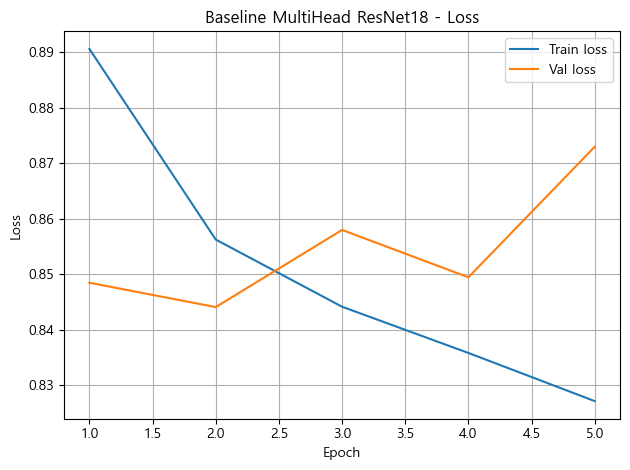

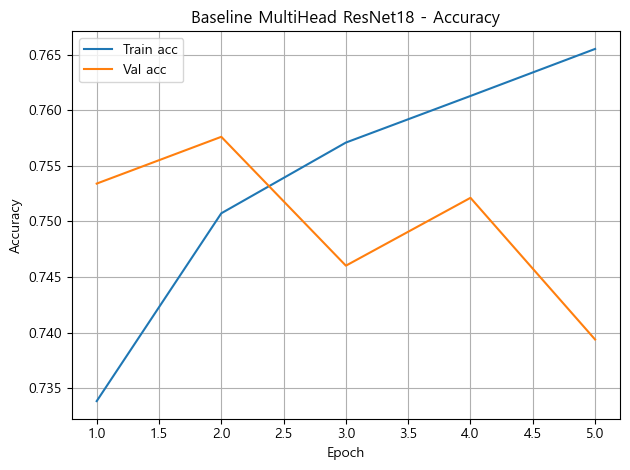

In [18]:
epochs = range(1, len(history["train_loss"]) + 1)

# 1) Loss 곡선
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline MultiHead ResNet18 - Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/03.loss_curve.png", dpi=150)
plt.show()

# 2) Accuracy 곡선
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train acc")
plt.plot(epochs, history["val_acc"],   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MultiHead ResNet18 - Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/03.acc_curve.png", dpi=150)
plt.show()


In [19]:
import numpy as np

print("keys:", history.keys())
print("train_loss:", history["train_loss"])
print("val_loss:", history["val_loss"])
print("train_acc:", history["train_acc"])
print("val_acc:", history["val_acc"])
print("epoch_time_sec:", history["epoch_time_sec"])

best_idx = int(np.argmin(history["val_loss"]))
best_epoch = best_idx + 1

print(f"\n[Best epoch] {best_epoch}")
print(f"  train_loss={history['train_loss'][best_idx]:.4f}, train_acc={history['train_acc'][best_idx]:.4f}")
print(f"  val_loss={history['val_loss'][best_idx]:.4f},   val_acc={history['val_acc'][best_idx]:.4f}")

times = np.array(history["epoch_time_sec"])
print(f"\nEpoch times (sec): {times}")
print(f"Average epoch time: {times.mean():.1f} sec (~{times.mean()/60:.2f} min)")


keys: dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'epoch_time_sec'])
train_loss: [0.890614691722913, 0.8562630982683165, 0.8441553875780137, 0.8358260951550421, 0.8271467391009754]
val_loss: [0.8484778883339027, 0.8440903122539999, 0.8579971700077226, 0.8494597129973925, 0.8729928315130935]
train_acc: [0.7338358880274605, 0.7507299126077608, 0.7570919887159456, 0.7612840543686256, 0.7655131088358881]
val_acc: [0.7534015048653542, 0.7576091875990043, 0.7460186128083277, 0.7521215207060421, 0.739378252998416]
epoch_time_sec: [3465.405419299961, 3430.3868656000122, 3434.004837699933, 3232.1374543999555, 3447.705290599959]

[Best epoch] 2
  train_loss=0.8563, train_acc=0.7507
  val_loss=0.8441,   val_acc=0.7576

Epoch times (sec): [3465.4054193 3430.3868656 3434.0048377 3232.1374544 3447.7052906]
Average epoch time: 3401.9 sec (~56.70 min)


In [21]:
import pandas as pd

df_hist = pd.DataFrame({
    "epoch": list(epochs),
    "train_loss": history["train_loss"],
    "train_acc":  history["train_acc"],
    "val_loss":   history["val_loss"],
    "val_acc":    history["val_acc"],
})

df_hist.to_csv("../data/processed/03.history.csv", index=False)
df_hist.head()


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.890615,0.733836,0.848478,0.753402
1,2,0.856263,0.750730,0.844090,0.757609
2,3,0.844155,0.757092,0.857997,0.746019
3,4,0.835826,0.761284,0.849460,0.752122
4,5,0.827147,0.765513,0.872993,0.739378


In [22]:
# 모델 가중치 저장 (baseline 버전)
torch.save(
    model.state_dict(),
    "models/02.resnet18_multhead_epoch10.pth"
)
